#MNIST ma’lumotlarini tayyorlash

* torchvision kutubxonasi yordamida MNIST ma’lumotlar to‘plamini yuklab oling.
* Ma’lumotlarni tensorlarga o‘tkazing.
* DataLoader yordamida o‘rgatish uchun tayyorlang.

In [7]:
#Kutubxonalar
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [8]:
#Ma'lumotni yuklash

# Rasmni tensorga o'tkazish (0-255 -> 0-1 oralig'iga normallashtiradi)
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [9]:
#DataLoader yordamida o‘rgatish uchun tayyorlaymiz

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train hajmi:", len(train_dataset))
print("Test hajmi:", len(test_dataset))

Train hajmi: 60000
Test hajmi: 10000


#Model arxitekturasini yaratish

Kiruvchi qatlamda 784 ta neyron (28x28 piksel), yashirin qatlamda 128 ta neyron (ReLU aktivatsiya funksiyasi bilan) va chiquvchi qatlamda 10 ta neyron (0 dan 9 gacha bo‘lgan raqamlar uchun) bo‘lgan nn.Sequential modelini yarating.

In [10]:
model = nn.Sequential(
    nn.Flatten(),          # 28x28 rasmni 784 ta songa "yozadi"
    nn.Linear(784, 128),   # kiruvchi qatlam -> yashirin qatlam (128 neyron)
    nn.ReLU(),             # aktivlashtirish funksiyasi
    nn.Linear(128, 10)     # yashirin qatlam -> chiquvchi qatlam (10 klass: 0-9)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


#Yo‘qotish funksiyasi va optimayzerni sozlash

Ko‘p klassli tasniflash uchun nn.CrossEntropyLoss yo‘qotish funksiyasini va optim.SGD optimayzerini lr=0.01 (learning rate) bilan sozlang.

In [11]:
criterion = nn.CrossEntropyLoss()  # ko'p klassli klassifikatsiya uchun
optimizer = optim.SGD(model.parameters(), lr=0.01)

#Modelni shug‘ullantirish va natijani tahlil qilish

* 5 ta epocha davomida modelni shug‘ullantiradigan tsikl yaratamiz

* Har bir epocha oxirida o‘rtacha yo‘qotish qiymatini ekranga chiqaramiz

* Shug‘ullantirish jarayonidan so‘ng yo‘qotish grafigini chizamiz

Epoch 1/5 — O'rtacha yo'qotish: 1.2430
Epoch 2/5 — O'rtacha yo'qotish: 0.4970
Epoch 3/5 — O'rtacha yo'qotish: 0.3942
Epoch 4/5 — O'rtacha yo'qotish: 0.3537
Epoch 5/5 — O'rtacha yo'qotish: 0.3292


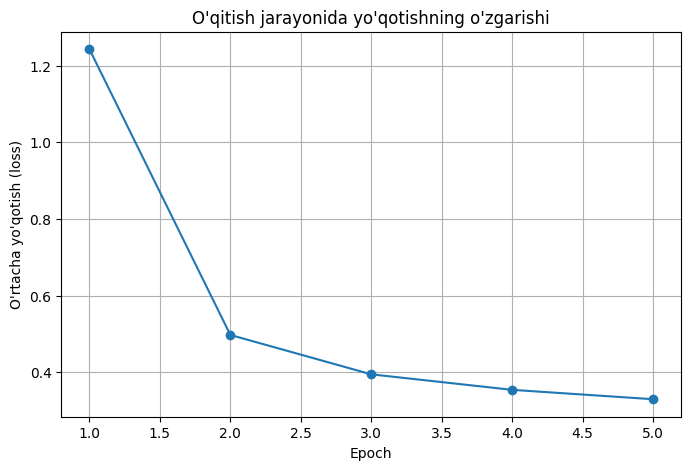

In [12]:
epochs = 5
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()          # avvalgi gradientlarni tozalash
        outputs = model(images)        # forward pass - bashorat
        loss = criterion(outputs, labels)  # yo'qotishni hisoblash
        loss.backward()                # backward pass - gradientlarni hisoblash
        optimizer.step()               # og'irliklarni yangilash (gradient descent)

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} — O'rtacha yo'qotish: {avg_loss:.4f}")

# Yo'qotish grafigini chizish
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("O'rtacha yo'qotish (loss)")
plt.title("O'qitish jarayonida yo'qotishning o'zgarishi")
plt.grid(True)
plt.show()

#Modelni test to'plamida sinash

In [13]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test to'plamidagi aniqlik: {100 * correct / total:.2f}%")

Test to'plamidagi aniqlik: 91.28%
